In [1]:
%%writefile requirements.txt
tensorflow>=2.16.1
numpy==1.26.4
scikit-learn>=1.4.2,<1.6
matplotlib>=3.8,<3.10
seaborn>=0.13.2
pandas>=2.2
streamlit
librosa>=0.10.2
ml-dtypes>=0.5.0

Writing requirements.txt


In [ ]:
!pip install -r requirements.txt

In [ ]:
!pip install kagglehub

## Importing Libraries

In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Data Preprocessing

###Training Image Preprocessing
Reference Link: https://keras.io/api/data_loading/image/

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.
Path to dataset files: /kaggle/input/new-plant-diseases-dataset


In [4]:
!ls -F {path}

'new plant diseases dataset(augmented)'/   test/
'New Plant Diseases Dataset(Augmented)'/


In [5]:
training_set = tf.keras.utils.image_dataset_from_directory(
    f'{path}/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None, # Added a fixed seed to address potential GPU-related issues during shuffling
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    format="tf",
    verbose=True,
)

Found 70295 files belonging to 38 classes.


### Validating Image Preprocessing

In [6]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    f'{path}/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    format="tf",
    verbose=True,
)

Found 17572 files belonging to 38 classes.


In [7]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [8]:
for x, y in training_set.take(1):
  print(x, x.shape)
  print(y, y.shape)

tf.Tensor(
[[[[170.   166.   167.  ]
   [169.5  165.5  166.5 ]
   [170.5  166.5  167.5 ]
   ...
   [148.5  142.5  144.5 ]
   [153.25 147.25 149.25]
   [151.25 145.25 147.25]]

  [[174.   170.   171.  ]
   [172.   168.   169.  ]
   [171.   167.   168.  ]
   ...
   [149.75 143.75 145.75]
   [150.25 144.25 146.25]
   [147.25 141.25 143.25]]

  [[174.   170.   171.  ]
   [172.   168.   169.  ]
   [171.   167.   168.  ]
   ...
   [148.5  142.5  144.5 ]
   [148.   142.   144.  ]
   [148.75 142.75 144.75]]

  ...

  [[158.75 170.25 154.  ]
   [149.5  161.   144.  ]
   [159.25 171.5  151.  ]
   ...
   [ 95.5   96.5   68.5 ]
   [ 96.    93.75  70.  ]
   [102.5  100.    77.  ]]

  [[155.5  169.   153.75]
   [146.5  160.75 142.75]
   [147.5  162.   141.75]
   ...
   [126.25 139.25 108.75]
   [137.25 149.75 121.75]
   [143.   155.5  127.5 ]]

  [[166.75 183.75 167.75]
   [143.25 160.25 141.75]
   [148.25 165.75 145.25]
   ...
   [118.   145.5  112.5 ]
   [120.5  148.   115.  ]
   [123.5  151.   11

### To avoid Overshooting
1. Choose small learning rate (default=0.001), we are taking 0.0001
2. There may be a chance of underfitting, so increase the number of neurons
3. Add more Convolution layer to extract more feature from images;
there may be a possibility that the model is unable to capture relevant features OR model is getting confused due to lack of features, hence add more features

## Building Model
Reference Link: https://stanford.edu/~shervine/teaching/cs-230/cheatsheet-convolutional-neural-networks/

In [9]:
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from tensorflow.keras.models import Sequential

In [10]:
model = Sequential()

In [11]:
## Building Convolution Layer
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=(128,128,3)))
model.add(Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(MaxPooling2D(pool_size=2,strides=2))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(MaxPooling2D(pool_size=2,strides=2))

In [13]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(MaxPooling2D(pool_size=2,strides=2))

In [14]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(MaxPooling2D(pool_size=2,strides=2))

In [15]:
model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=512,kernel_size=3,activation='relu'))
model.add(MaxPooling2D(pool_size=2,strides=2))

In [16]:
model.add(Dropout(0.25)) # To avoid overfitting: drop 25% of neurons

In [17]:
# Flattening the layer
model.add(Flatten())

In [18]:
# Building the Hidden Layer

# model.add(Dense(units=1024,activation='relu'))
# Increasing the number of neurons to avoid overshooting

model.add(Dense(units=1500,activation='relu'))

In [19]:
model.add(Dropout(0.4)) # drop 40% of neurons to avoid overfitting

In [20]:
# Output layer
# Since we have 38 classes and we want the probability for each class
model.add(Dense(units=38,activation='softmax'))

## Compiling Model

In [21]:
# default learning_rate=0.001
# model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [22]:
# One thing we could do to avoid the overshooting of loss function is to reduce the learning rate
# Reference Link: https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam
model.compile(optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        57,038 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,842,762 (29.92 MB)

 Trainable params: 7,842,762 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

## Model Training

In [24]:
training_history = model.fit(
    x=training_set,
    epochs=10, # You can adjust the number of epochs as needed
    validation_data=validation_set
)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 76s 26ms/step - accuracy: 0.5857 - loss: 1.3968 - val_accuracy: 0.8124 - val_loss: 0.5902
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - accuracy: 0.8512 - loss: 0.4666 - val_accuracy: 0.9121 - val_loss: 0.2813
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - accuracy: 0.9106 - loss: 0.2775 - val_accuracy: 0.9269 - val_loss: 0.2289
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - accuracy: 0.9410 - loss: 0.1808 - val_accuracy: 0.9505 - val_loss: 0.1567
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.9548 - loss: 0.1379 - val_accuracy: 0.9489 - val_loss: 0.1653
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.9630 - loss: 0.1108 - val_accuracy: 0.9553 - val_loss: 0.1451
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.9714 - loss: 0.0872 - val_accuracy: 0.9558 - val_loss: 0.1432
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.9753 -

## Model Evaluation

In [25]:
# Model evaluation on Training set
train_loss, train_accuracy = model.evaluate(training_set)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.9928 - loss: 0.0226


In [26]:
print(train_loss, train_accuracy)

0.02261388674378395 0.9927732944488525


In [27]:
# Model evaluation on Validation set
val_loss, val_accuracy = model.evaluate(validation_set)

550/550 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9689 - loss: 0.1032


In [28]:
print(val_loss, val_accuracy)

0.10323166847229004 0.9688709378242493


## Saving Model

In [29]:
# model.save("trained_model.h5") # Another type of extension (Heavy)
model.save("trained_model.keras")

In [30]:
training_history.history

{'accuracy': [0.585660457611084,
  0.8511984944343567,
  0.9105910658836365,
  0.940963089466095,
  0.9548332095146179,
  0.9630272388458252,
  0.9713635444641113,
  0.975332498550415,
  0.9796571731567383,
  0.982146680355072],
 'loss': [1.3968110084533691,
  0.46657952666282654,
  0.2774535119533539,
  0.1808205544948578,
  0.13789916038513184,
  0.11078367382287979,
  0.08723378926515579,
  0.07534356415271759,
  0.06168569251894951,
  0.05538618564605713],
 'val_accuracy': [0.812428891658783,
  0.9121329188346863,
  0.9268723130226135,
  0.9504894018173218,
  0.9488959908485413,
  0.9552697539329529,
  0.9558388590812683,
  0.9687570929527283,
  0.9562941193580627,
  0.9688709378242493],
 'val_loss': [0.5902110934257507,
  0.28127381205558777,
  0.22891424596309662,
  0.15665270388126373,
  0.1653318554162979,
  0.14514470100402832,
  0.14317141473293304,
  0.1001964658498764,
  0.14352238178253174,
  0.10323169827461243]}

In [31]:
# Recording History in JSON format
import json
with open("training_hist.json", 'w') as f:
  json.dump(training_history.history, f)

## Accuracy Visualization

In [32]:
training_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [33]:
training_history.history['accuracy']

[0.585660457611084,
 0.8511984944343567,
 0.9105910658836365,
 0.940963089466095,
 0.9548332095146179,
 0.9630272388458252,
 0.9713635444641113,
 0.975332498550415,
 0.9796571731567383,
 0.982146680355072]

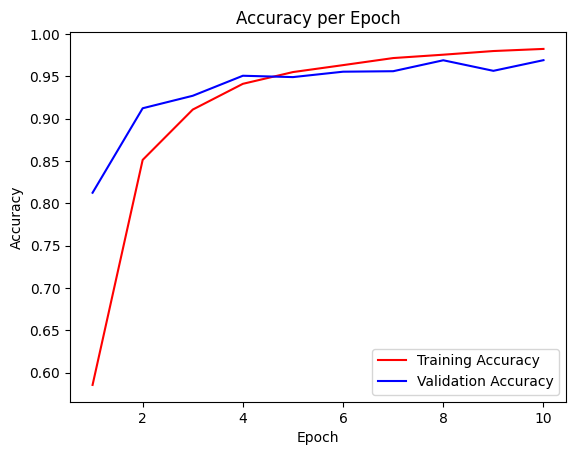

In [39]:
epochs = [i for i in range(1, 11)]
plt.plot(epochs, training_history.history['accuracy'], color='red', label='Training Accuracy')
plt.plot(epochs, training_history.history['val_accuracy'], color='blue', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy per Epoch')
plt.legend()
plt.show()

## Other Metrics for Evaluation

In [41]:
class_name = validation_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [42]:
# using validation_set as test_set since they are labelled
test_set = tf.keras.utils.image_dataset_from_directory(
    f'{path}/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False, # Shuffle set to false
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    format="tf",
    verbose=True,
)

Found 17572 files belonging to 38 classes.


In [43]:
# for each test image, the columns show the probability of belonging to a particular class
y_pred = model.predict(test_set)
y_pred, y_pred.shape

550/550 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step


(array([[9.99998093e-01, 1.53083374e-06, 9.99192729e-10, ...,
         6.24508786e-14, 1.18465186e-11, 1.73759379e-12],
        [9.99995351e-01, 1.79732399e-06, 7.96300537e-09, ...,
         3.82518317e-13, 6.36154974e-12, 5.59067809e-12],
        [1.00000000e+00, 1.77808657e-09, 1.99777958e-10, ...,
         4.12791379e-19, 2.67294172e-14, 3.56517650e-15],
        ...,
        [8.47013779e-12, 7.87014141e-15, 5.35329736e-09, ...,
         4.90002885e-15, 1.45512129e-12, 1.00000000e+00],
        [4.17270737e-13, 4.51730241e-16, 2.09312900e-09, ...,
         2.58693129e-14, 5.22758215e-13, 1.00000000e+00],
        [1.16395825e-11, 6.24096001e-12, 8.57704907e-10, ...,
         1.32886887e-11, 6.15170193e-10, 9.99997616e-01]], dtype=float32),
 (17572, 38))

In [44]:
# tf.argmax() -> find idx of maximum value across the columns for each row.
predicted_categories = tf.argmax(y_pred, axis=1)
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [45]:
# Storing the actual class from the test_set
true_categories = tf.concat([y for x, y in test_set], axis=0)
true_categories # one hot encoding

<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [47]:
Y_true = tf.argmax(true_categories, axis=1)
Y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

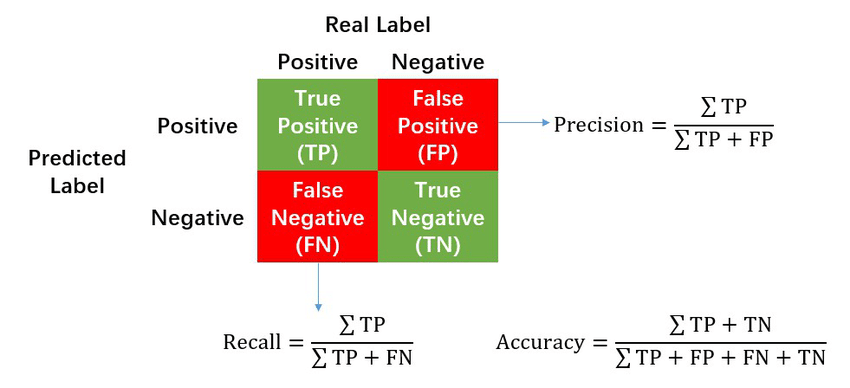

Reference Link: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html

In [50]:
from sklearn.metrics import classification_report, confusion_matrix

In [49]:
print(classification_report(Y_true, predicted_categories, target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.96      0.97      0.97       504
                                 Apple___Black_rot       1.00      0.98      0.99       497
                          Apple___Cedar_apple_rust       0.97      0.99      0.98       440
                                   Apple___healthy       0.96      0.96      0.96       502
                               Blueberry___healthy       0.95      0.98      0.97       454
          Cherry_(including_sour)___Powdery_mildew       0.98      0.99      0.98       421
                 Cherry_(including_sour)___healthy       0.95      1.00      0.97       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.94      0.92      0.93       410
                       Corn_(maize)___Common_rust_       0.99      1.00      0.99       477
               Corn_(maize)___Northern_Leaf_Blight       0.94      0.96      0.

### Classification Report Interpretation

The CNN achieved an overall validation accuracy of 96.89% with macro and weighted F1-scores of 0.97 across 38 plant disease classes. Most classes achieved precision and recall above 0.95, showing strong classification performance on the validation dataset.

However, some visually similar tomato disease classes showed weaker performance. For example, Tomato Target Spot had a lower recall of 0.78, while Tomato Late Blight, Septoria Leaf Spot, and Spider Mites also showed comparatively lower precision or recall. This suggests that the model may confuse diseases with similar leaf discoloration, lesion shape, or texture patterns.

These results motivate the use of Grad-CAM explainability and future real-world image testing to better understand model behavior beyond clean validation images.

In [54]:
cm = confusion_matrix(Y_true, predicted_categories)
cm.shape

(38, 38)

### Confusion Matrix

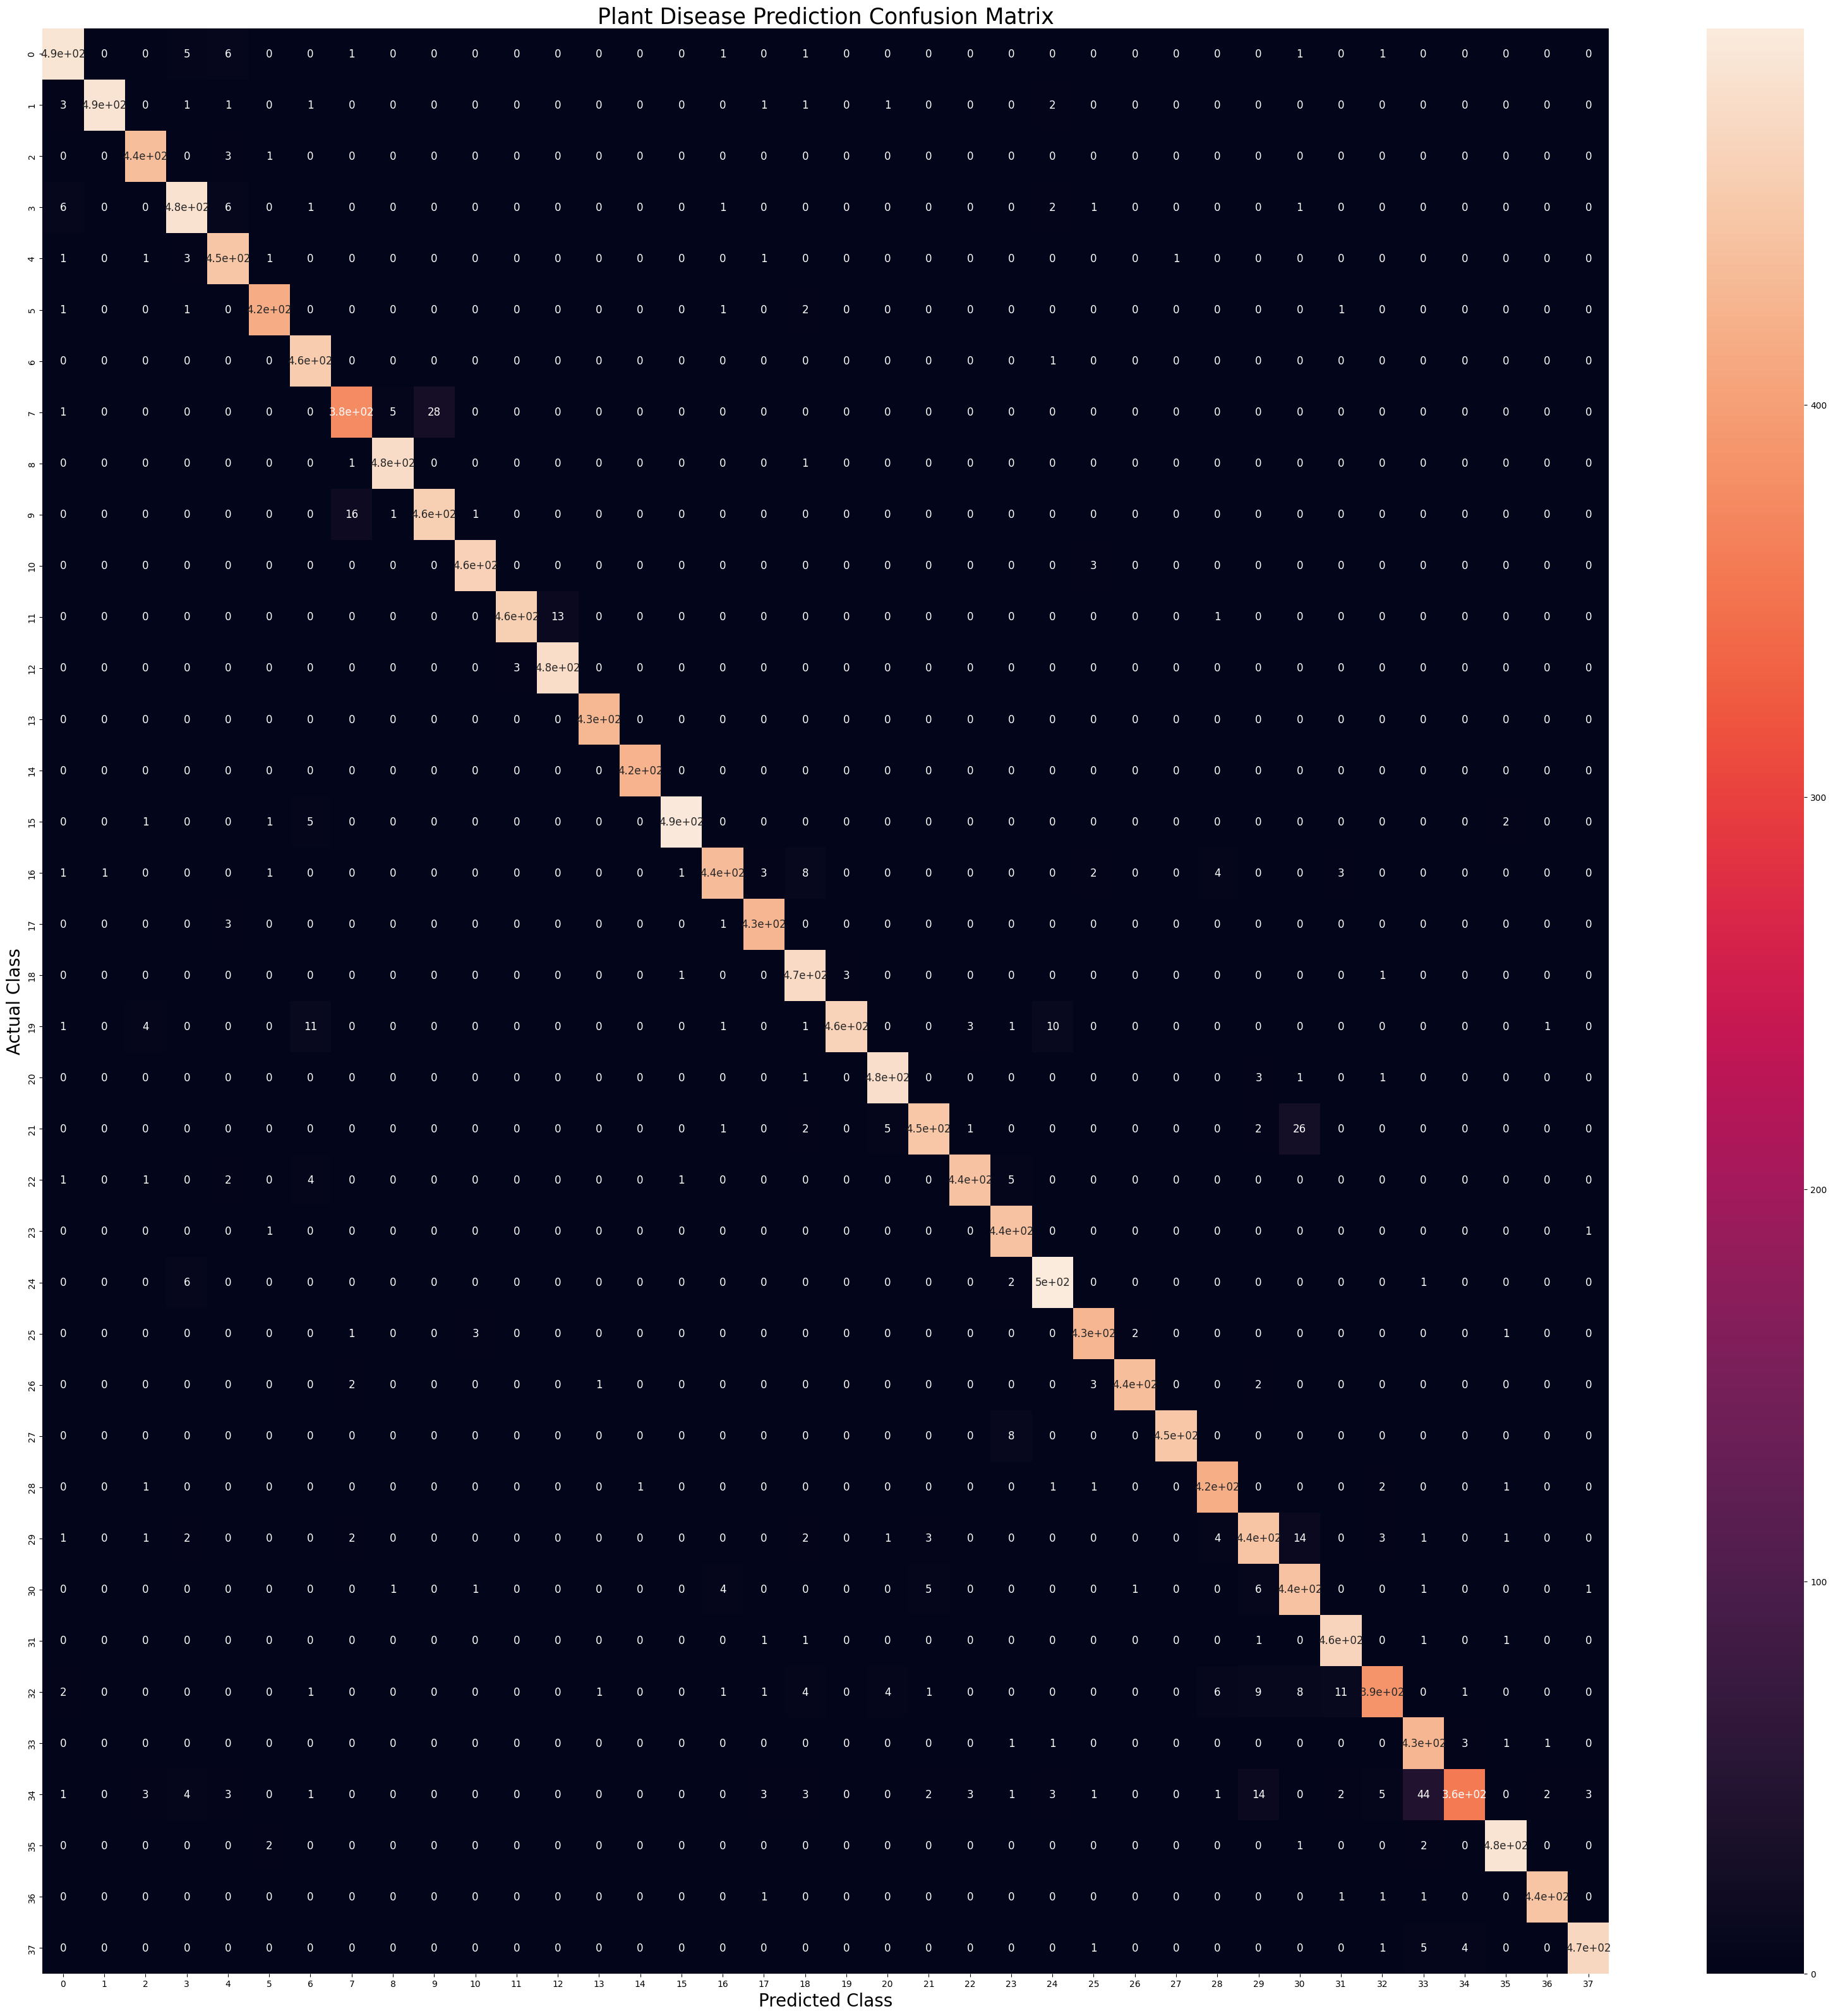

In [61]:
plt.figure(figsize=(40,40))
sns.heatmap(cm, annot=True, annot_kws={'size':12})
plt.xlabel('Predicted Class',fontsize=20)
plt.ylabel('Actual Class', fontsize=20)
plt.title('Plant Disease Prediction Confusion Matrix', fontsize=25)
plt.show()